In [7]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed

importlib.reload(aaro_draft)
importlib.reload(Conor)

<module 'Conor' from '/workspaces/Research-Skills-for-Financial-Mathematics/Conor.py'>

In [8]:
import aaro_draft as ad
import Conor as c

In [9]:
cfg = c.ExpConfig(
    alpha=0.5,
    label="alpha=0.5"
)
results = c.run_experiment([cfg], n_jobs=-1)



--- Running: alpha=0.5 ---
    Done. Final mean VPI: -39.026


In [10]:
results["alpha=0.5"]["vpi"][:10]

array([-154.08755912, -225.46534033, -154.37506579, -134.3632921 ,
       -143.67085166, -153.0676052 ,  -85.34538083,  -85.61672906,
       -106.23092755,  -78.15115882])

### Why very large values of $\alpha$ (e.g., 100 or 500) do not work well

In the algorithm, the exploration bonus in the UCB update is

$$
\text{UCB} = \frac{\text{scaling}}{n^\alpha} + \text{scaling}\cdot \text{radius},
$$

where $n$ is the number of visits to the active node.

When $\alpha$ is extremely large (e.g., 100 or 500), the term $n^{-\alpha}$ decays **extremely quickly**.

For example:

- $1 / 2^{100} \approx 7.9 \times 10^{-31}$
- $1 / 3^{100} \approx 5.2 \times 10^{-48}$

After only one or two visits, the exploration bonus from the $n^{-\alpha}$ term becomes essentially **zero**.

As a result:

- The algorithm stops encouraging exploration very early.
- The Q-value updates become almost purely greedy.
- The agent may commit prematurely to suboptimal regions of the state–action space.
- The adaptive partitioning receives poor information, which can degrade learning performance.

Although the radius term still provides some spatial optimism, the rapid collapse of $n^{-\alpha}$ makes the algorithm behave much less like a UCB-style method.

For this reason, extremely large values such as $\alpha = 100$ or $\alpha = 500$ are not very informative in practice. More meaningful comparisons usually occur for values such as

$$
\alpha \in [0.01, 1],
$$

where the exploration bonus decays at a reasonable rate.


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -40.208

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -35.784

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -39.952

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -39.017

--- Running: alpha=1 ---
    Done. Final mean VPI: -36.259

--- Running: alpha=5 ---
    Done. Final mean VPI: -32.022

--- Running: alpha=10 ---
    Done. Final mean VPI: -33.580

--- Running: alpha=50 ---
    Done. Final mean VPI: -34.715


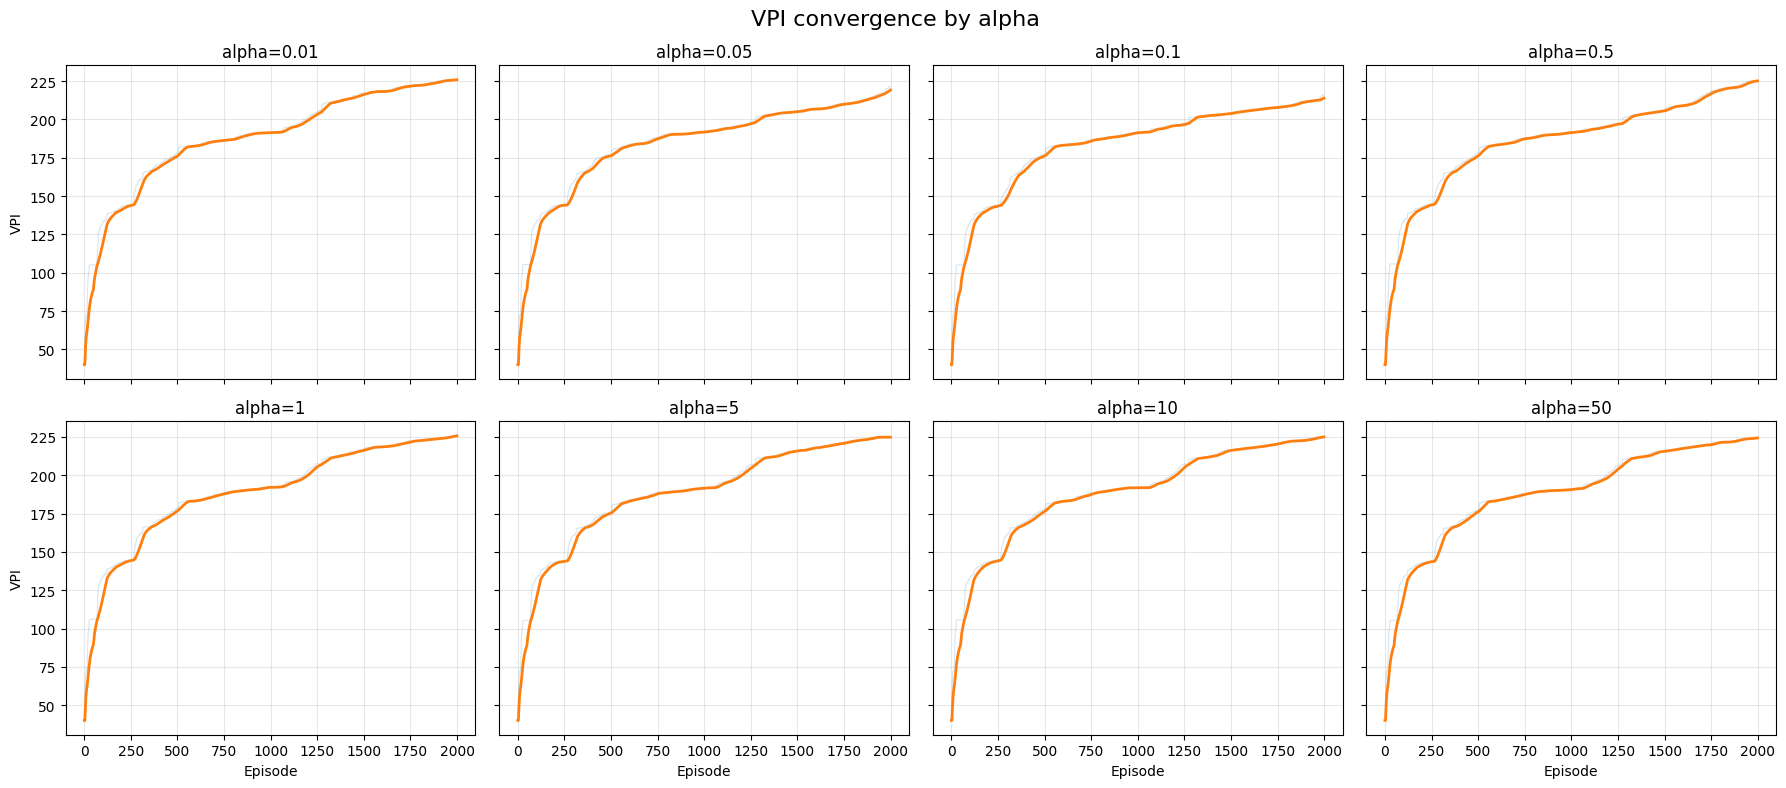

In [11]:
import numpy as np
import matplotlib.pyplot as plt
#alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]


alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()

smooth_window = 50

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = np.asarray(results[label]["arms"], dtype=float)
    episodes = np.arange(len(arms))

    cumsum = np.cumsum(np.insert(arms, 0, 0.0))
    smoothed = np.empty_like(arms)
    for i in range(len(arms)):
        start = max(0, i - smooth_window + 1)
        smoothed[i] = (cumsum[i + 1] - cumsum[start]) / (i - start + 1)

    ax.plot(episodes, arms, alpha=0.18, linewidth=0.8)
    ax.plot(episodes, smoothed, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("VPI")

fig.suptitle("VPI convergence by alpha", fontsize=16)
fig.tight_layout()
plt.show()

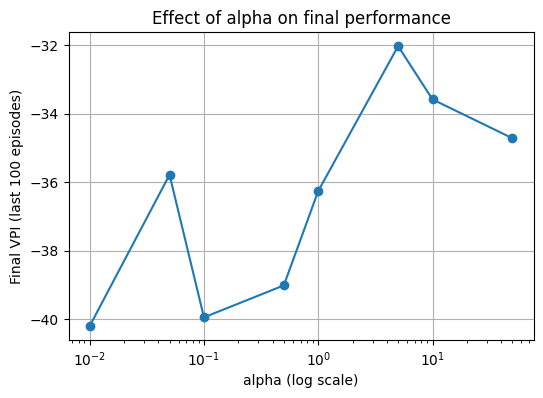

In [12]:


final_vpi = []

for a in alphas:
    label = f"alpha={a}"
    v = np.asarray(results[label]["vpi"], dtype=float)
    final_vpi.append(np.mean(v[-100:]))

plt.figure(figsize=(6,4))
plt.plot(alphas, final_vpi, marker='o')
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Effect of alpha on final performance")
plt.grid(True)
plt.show()


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -36.743

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -34.536

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -40.436

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -37.878

--- Running: alpha=1 ---
    Done. Final mean VPI: -37.990

--- Running: alpha=5 ---
    Done. Final mean VPI: -33.280

--- Running: alpha=10 ---
    Done. Final mean VPI: -34.600

--- Running: alpha=50 ---
    Done. Final mean VPI: -32.648


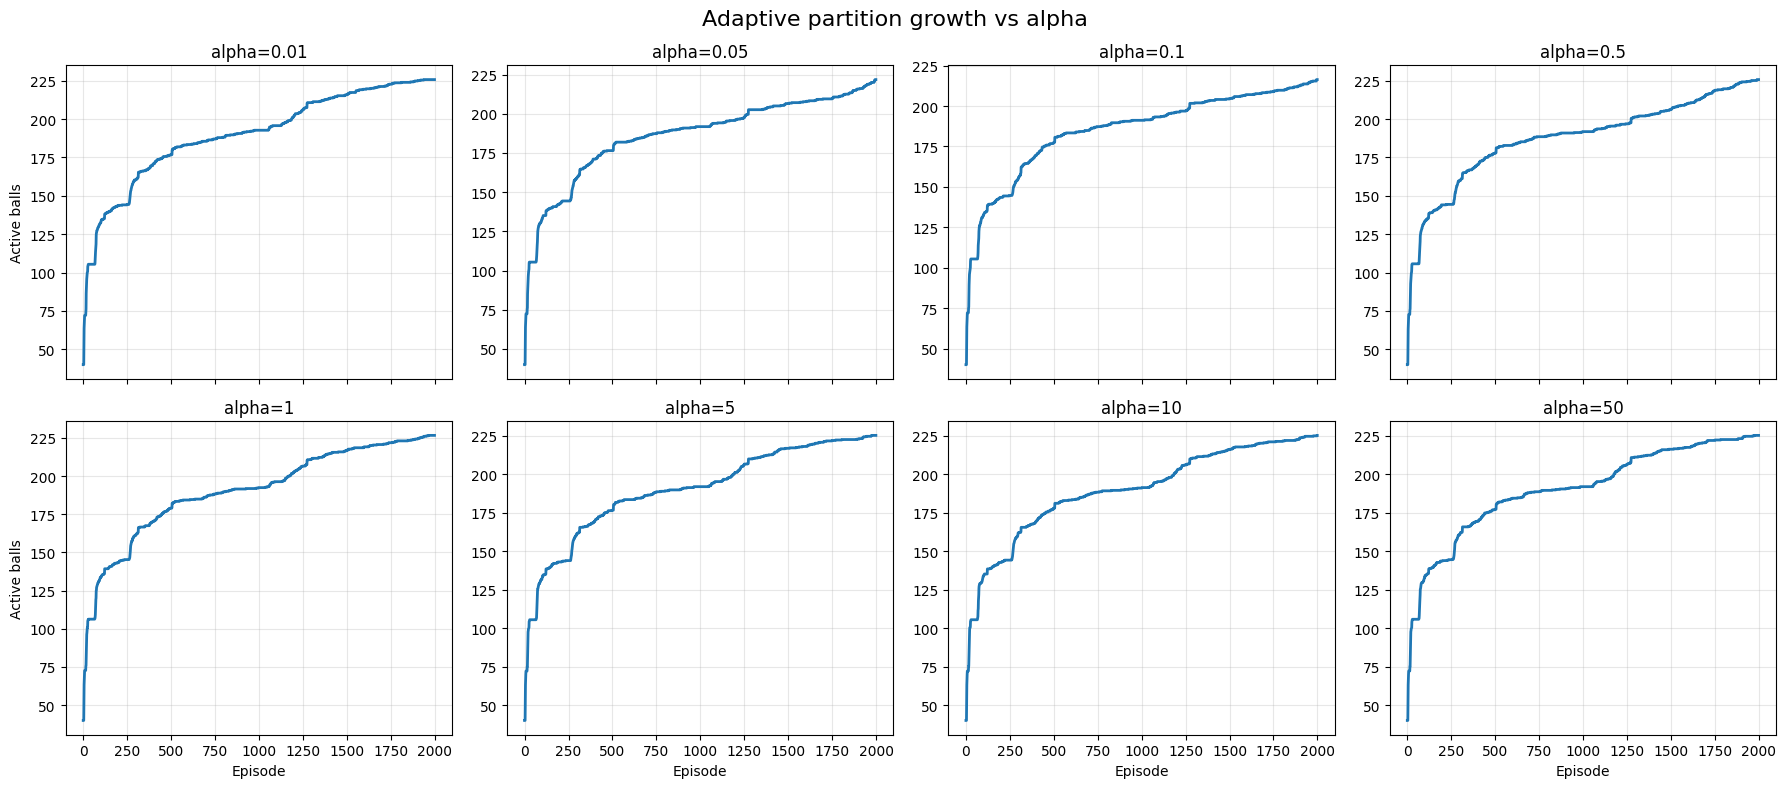

In [13]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)


fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.ravel()

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = results[label]["arms"]

    ax.plot(arms, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("Active balls")

fig.suptitle("Adaptive partition growth vs alpha", fontsize=16)
fig.tight_layout()
plt.show()

The above plot explains how quick the partition grows. We seee rapid growth early on and then a plateua arond 200 ish. Overall the algorithim doesnt seem to be vey sensitive to alpha as there is little difference between alpha = 0.1 and alpha = 50

In [15]:
n_simulations = 10 

print(f"Starting {n_simulations} parallel experiments...")

# Run the parallel experiment loop using the function from your imported module
# This triggers run_single_experiment_iteration(i) for i in range(0, 50)
list_of_results = Parallel(n_jobs=-1)(
    delayed(ad.run_single_experiment_iteration)(i) for i in range(n_simulations)
)

# Process the results into a mean estimate (VPI)
vpi_df = pd.DataFrame(list_of_results).T
vpi_estimate = vpi_df.mean(axis=1)

# Generate the plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(vpi_estimate)), vpi_estimate, label='VPI (Average Reward)', color='blue')
plt.xlabel("Episode")
plt.ylabel("Value Performance Index")
plt.title("Agent Performance: VPI vs Episode (Portfolio Optimization)")
plt.legend()
plt.grid(True)
plt.show()

# final average reward achieved
print(f"Final Average Reward after {ad.nEps} episodes: {vpi_estimate.iloc[-1]:.4f}")

Starting 50 parallel experiments...


**************************************************
Running experiment
**************************************************
**************************************************
Running experiment
**************************************************
**************************************************
Experiment complete
**************************************************
**************************************************
Saving data
**************************************************
**************************************************
Experiment complete
**************************************************
**************************************************
Saving data
**************************************************
**************************************************
Running experiment
**************************************************
**************************************************
Running experiment
**************************************************
********************************************

KeyboardInterrupt: 

In [16]:

cfgs = [
    c.ExpConfig(alpha=0.5, starting_state=s0, rho=30.0, label=f"start={s0}|alpha=0.5")
    for s0 in [-20, -10, 0, 4, 10, 20]
]

res = c.run_experiment(cfgs, n_jobs=1)
print(res.keys())


--- Running: start=-20|alpha=0.5 ---
    Done. Final mean VPI: -2267.567

--- Running: start=-10|alpha=0.5 ---
    Done. Final mean VPI: -526.451

--- Running: start=0|alpha=0.5 ---
    Done. Final mean VPI: -177.216

--- Running: start=4|alpha=0.5 ---
    Done. Final mean VPI: -48.202

--- Running: start=10|alpha=0.5 ---
    Done. Final mean VPI: -0.802

--- Running: start=20|alpha=0.5 ---
    Done. Final mean VPI: -268.891
dict_keys(['start=-20|alpha=0.5', 'start=-10|alpha=0.5', 'start=0|alpha=0.5', 'start=4|alpha=0.5', 'start=10|alpha=0.5', 'start=20|alpha=0.5'])


### Experiment to vary over multiple alphas and multiple $x_0$. 


--- Running: start=-20|alpha=0.1 ---
    Done. Final mean VPI: -2276.020

--- Running: start=-20|alpha=0.5 ---
    Done. Final mean VPI: -2267.567

--- Running: start=-20|alpha=5.0 ---
    Done. Final mean VPI: -2276.199

--- Running: start=-10|alpha=0.1 ---
    Done. Final mean VPI: -522.244

--- Running: start=-10|alpha=0.5 ---
    Done. Final mean VPI: -526.451

--- Running: start=-10|alpha=5.0 ---
    Done. Final mean VPI: -533.811

--- Running: start=0|alpha=0.1 ---
    Done. Final mean VPI: -185.641

--- Running: start=0|alpha=0.5 ---
    Done. Final mean VPI: -177.216

--- Running: start=0|alpha=5.0 ---
    Done. Final mean VPI: -169.811

--- Running: start=4|alpha=0.1 ---
    Done. Final mean VPI: -48.153

--- Running: start=4|alpha=0.5 ---
    Done. Final mean VPI: -48.202

--- Running: start=4|alpha=5.0 ---
    Done. Final mean VPI: -48.135

--- Running: start=10|alpha=0.1 ---
    Done. Final mean VPI: -0.867

--- Running: start=10|alpha=0.5 ---
    Done. Final mean VPI: -0.

,starting_state,alpha,final_vpi_100,final_arms_100,mean_vpi_all,max_arms
0,-20,0.1,-2276.019687,205.585,-2286.966241,205.6
1,-20,0.5,-2267.567393,205.882,-2276.731049,205.9
2,-20,5.0,-2276.198922,206.200,-2284.142783,206.2
3,-10,0.1,-522.244470,207.961,-537.553753,208.3
4,-10,0.5,-526.451433,207.532,-540.270101,207.7
5,-10,5.0,-533.810985,207.289,-546.707272,207.4
6,0,0.1,-185.641006,263.848,-194.306892,264.1
7,0,0.5,-177.215773,266.338,-186.191148,266.5
8,0,5.0,-169.810613,268.114,-178.254735,268.3
9,4,0.1,-48.153303,202.786,-53.050837,205.0


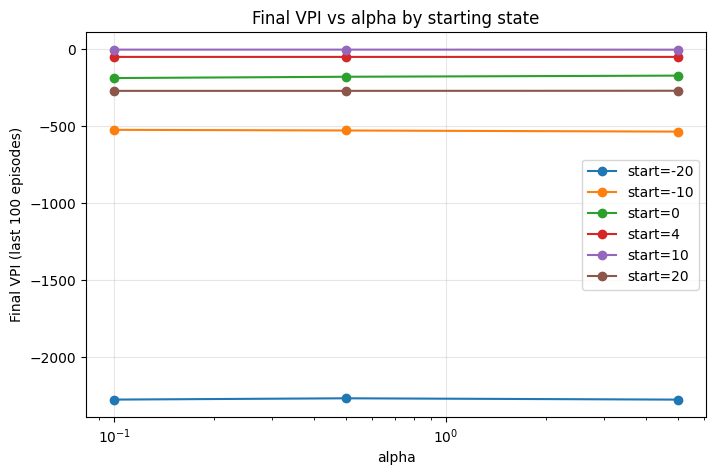

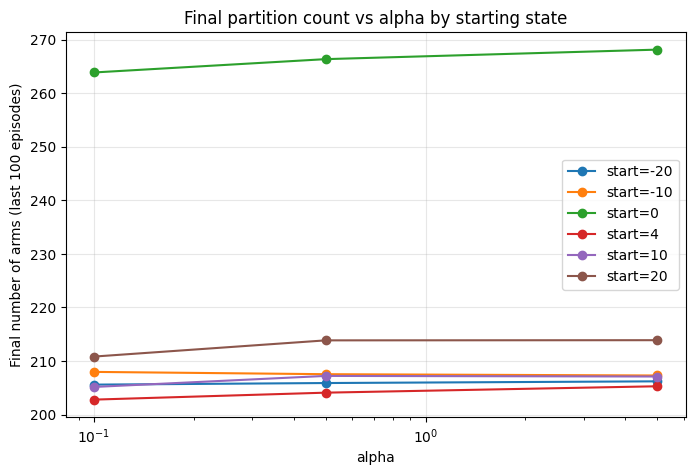

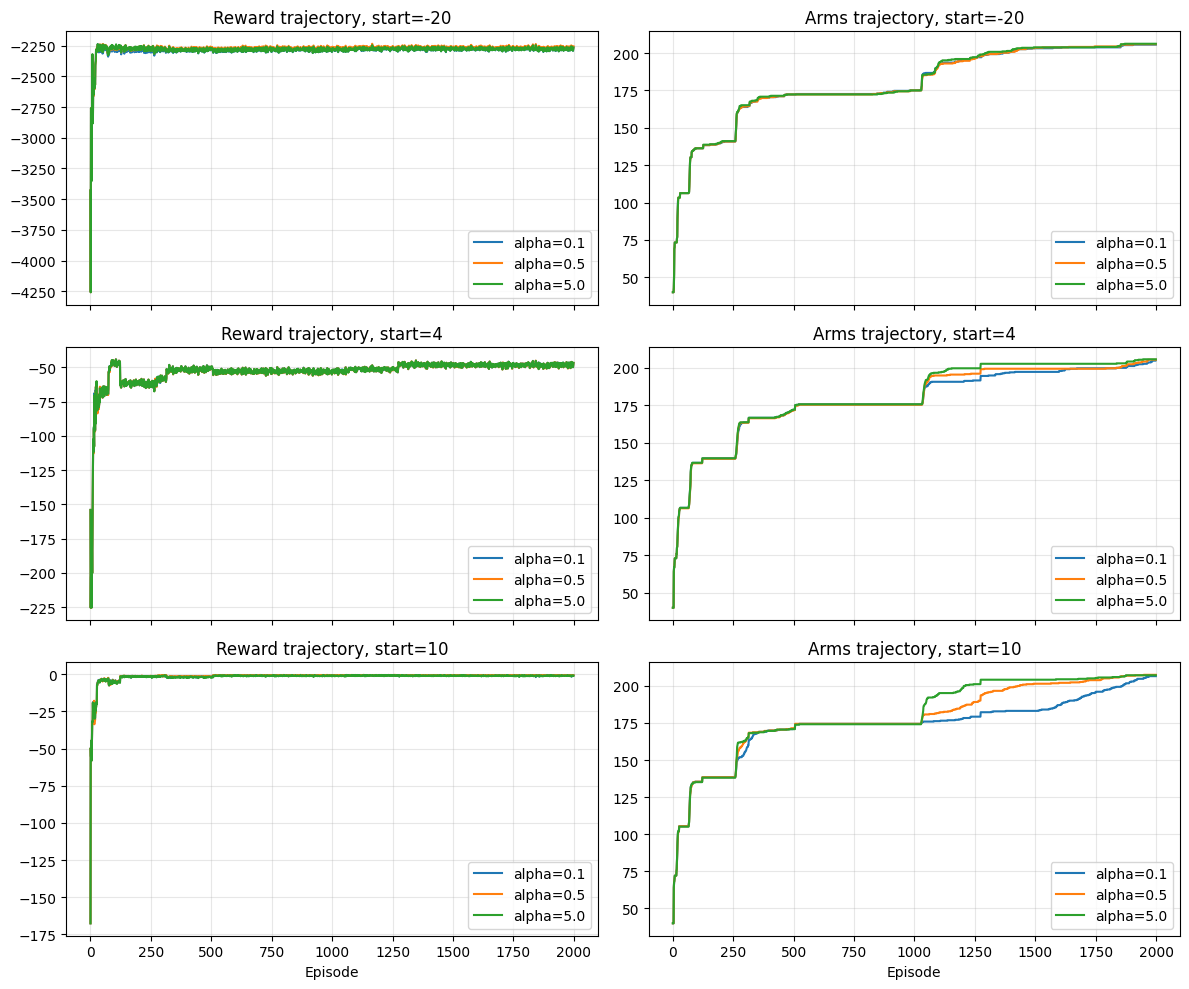

,starting_state,alpha,final_vpi_100,final_arms_100
1,-20,0.5,-2267.567393,205.882
3,-10,0.1,-522.244470,207.961
8,0,5.0,-169.810613,268.114
11,4,5.0,-48.135172,205.279
13,10,0.5,-0.802201,207.211
17,20,5.0,-268.205028,213.880


In [17]:


# -----------------------------
# Experiment settings
# -----------------------------
starting_states = [-20, -10, 0, 4, 10, 20]
alphas = [0.1, 0.5, 5.0]
rho_val = 30.0

# -----------------------------
# Run sweep
# -----------------------------
all_results = {}

for s0 in starting_states:
    configs = [
        c.ExpConfig(
            alpha=a,
            starting_state=s0,
            rho=rho_val,
            label=f"start={s0}|alpha={a}"
        )
        for a in alphas
    ]
    all_results[s0] = c.run_experiment(configs, n_jobs=1)

# -----------------------------
# Build summary table
# -----------------------------
rows = []

for s0 in starting_states:
    for a in alphas:
        label = f"start={s0}|alpha={a}"
        vpi = np.asarray(all_results[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results[s0][label]["arms"], dtype=float)

        rows.append({
            "starting_state": s0,
            "alpha": a,
            "final_vpi_100": vpi[-100:].mean(),
            "final_arms_100": arms[-100:].mean(),
            "mean_vpi_all": vpi.mean(),
            "max_arms": arms.max()
        })

summary_df = pd.DataFrame(rows).sort_values(["starting_state", "alpha"])
display(summary_df)

# -----------------------------
# Plot 1: Final VPI vs alpha
# -----------------------------
plt.figure(figsize=(8, 5))

for s0 in starting_states:
    sub = summary_df[summary_df["starting_state"] == s0]
    plt.plot(sub["alpha"], sub["final_vpi_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Final VPI vs alpha by starting state")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: Final arms vs alpha
# -----------------------------
plt.figure(figsize=(8, 5))

for s0 in starting_states:
    sub = summary_df[summary_df["starting_state"] == s0]
    plt.plot(sub["alpha"], sub["final_arms_100"], marker="o", label=f"start={s0}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Final number of arms (last 100 episodes)")
plt.title("Final partition count vs alpha by starting state")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot 3: Reward trajectories
# -----------------------------
starts_to_show = [-20, 4, 10]

fig, axes = plt.subplots(len(starts_to_show), 2, figsize=(12, 10), sharex=True)

for i, s0 in enumerate(starts_to_show):
    for a in alphas:
        label = f"start={s0}|alpha={a}"
        vpi = np.asarray(all_results[s0][label]["vpi"], dtype=float)
        arms = np.asarray(all_results[s0][label]["arms"], dtype=float)

        axes[i, 0].plot(vpi, label=f"alpha={a}")
        axes[i, 1].plot(arms, label=f"alpha={a}")

    axes[i, 0].set_title(f"Reward trajectory, start={s0}")
    axes[i, 1].set_title(f"Arms trajectory, start={s0}")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 0].legend()
    axes[i, 1].legend()

axes[-1, 0].set_xlabel("Episode")
axes[-1, 1].set_xlabel("Episode")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: best alpha by start
# -----------------------------
best_by_start = summary_df.loc[
    summary_df.groupby("starting_state")["final_vpi_100"].idxmax()
][["starting_state", "alpha", "final_vpi_100", "final_arms_100"]]

display(best_by_start)

The benchmark is highly sensitive to the initial state. Performance improves substantially when the process starts near the feasible action region, while negative initial states perform much worse. Although the exploration decay parameter $ \alpha $ interacts with the part of the state space explored early on, the best-performing values remain in a fairly narrow range and the performance differences between them are modest.

The partition counts are also revealing. Aside from the start at 0, which produced noticeably more arms, the number of active partitions stays in a tight band of roughly 205–213 across starting states. This means the sharp decline in performance for negative starts is not being driven by a failure to refine the partition. Instead, it points to a structural difficulty in the control problem itself: the action space is bounded to a feasible region that aligns much better with positive states than with negative ones.

So the main takeaways are:
- Performance improves dramatically when the initial state lies near the feasible action region.
- Different α values can be preferred in different parts of the state space, but the differences are small enough to suggest moderate robustness.
- Large swings in performance are not matched by similarly large swings in partition growth, which suggests adaptive discretization is not the main bottleneck in this toy problem